DISTRIBUTION FITTING

📊 Column: culmen_length_mm
  Best fitting distribution: Gamma
  p-value: 0.0715
  Good fit: Yes

📊 Column: culmen_depth_mm
  Best fitting distribution: Gamma
  p-value: 0.0189
  Good fit: No

📊 Column: flipper_length_mm
  Best fitting distribution: Gamma
  p-value: 0.0033
  Good fit: No

📊 Column: body_mass_g
  Best fitting distribution: Gamma
  p-value: 0.2542
  Good fit: Yes

📊 Column: culmen_area_mm2
  Best fitting distribution: Gamma
  p-value: 0.8060
  Good fit: Yes

📊 Column: flipper_to_mass_ratio
  Best fitting distribution: Gamma
  p-value: 0.4593
  Good fit: Yes


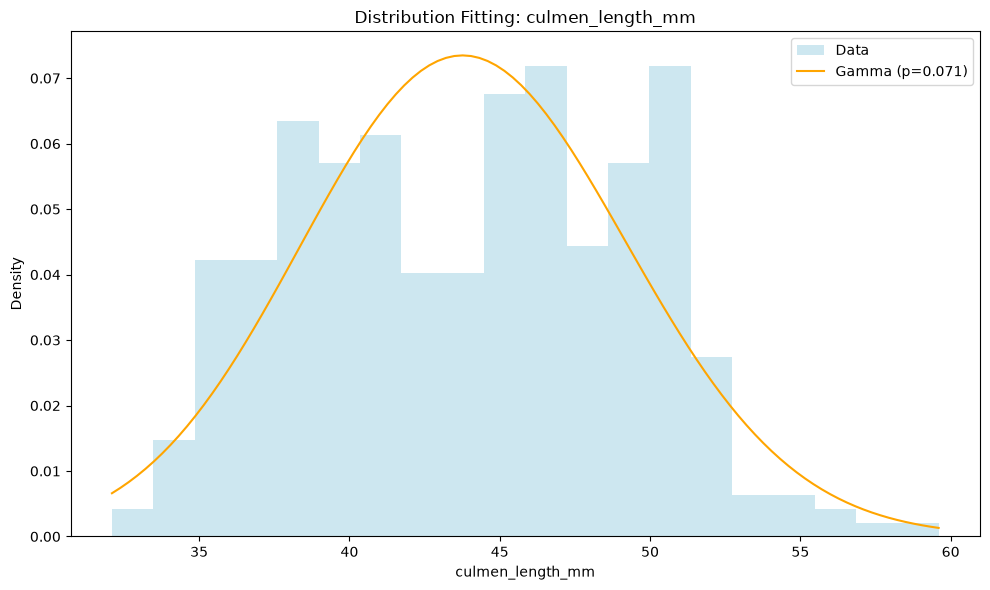

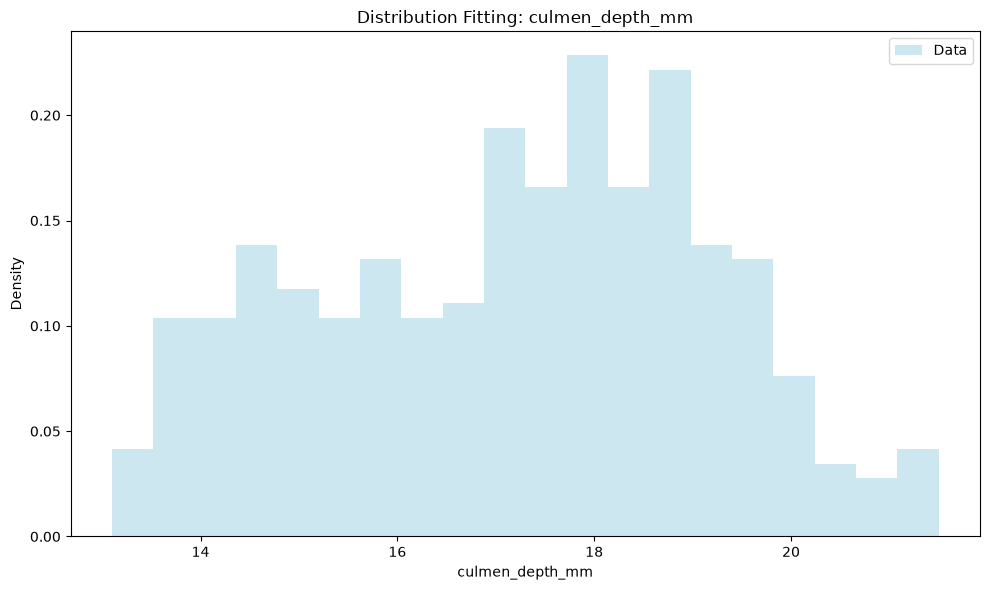

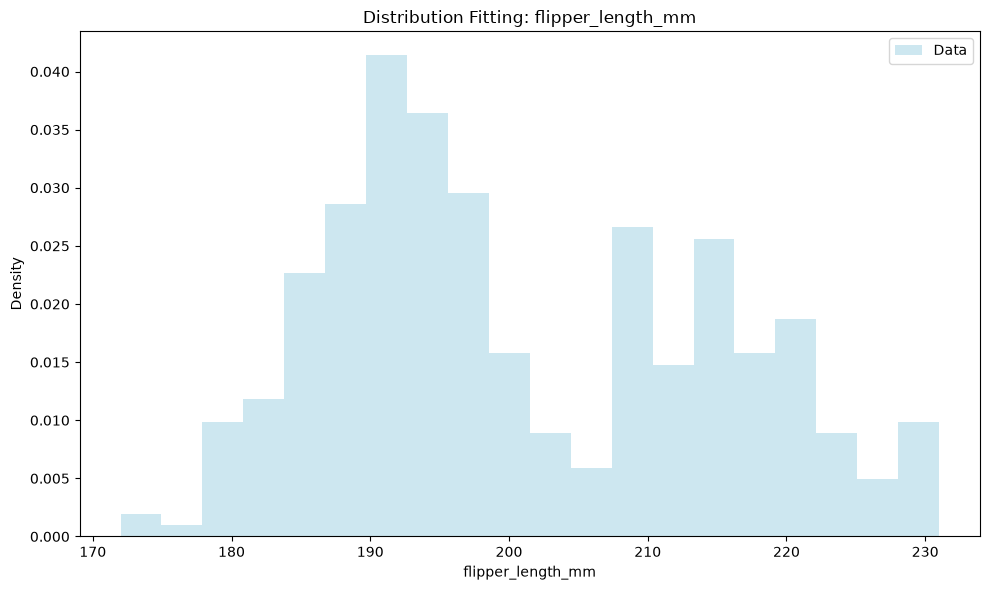


 Distribution fitting results saved to '../reports/distribution_fitting_summary.csv'


In [1]:
import sys
sys.path.append('..')

import pandas as pd 

import numpy as np 

from src.data_loader import DataLoader 

from src.statistics import StatisticalAnalyzer 
from scipy import stats
import matplotlib.pyplot as plt 

import seaborn as sns 

 

# Load cleaned data 

loader = DataLoader(data_dir="../data") 

df = pd.read_csv(loader.processed_dir / "cleaned_data.csv") 

 

print("=" * 60) 

print("DISTRIBUTION FITTING") 

print("=" * 60) 

 

# Select numeric columns 

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns 

 

# ==================== 1. FIT DISTRIBUTIONS ==================== 

def fit_distributions_to_column(data, column_name): 

    """Fit multiple distributions to a column of data.""" 

    results = {} 

    distributions = { 

        'Normal': stats.norm, 

        'Exponential': stats.expon, 

        'Gamma': stats.gamma, 

        'Lognormal': stats.lognorm, 

        'Uniform': stats.uniform 

    } 

     

    for dist_name, dist in distributions.items(): 

        try: 

            # Fit distribution 

            params = dist.fit(data) 

             

            # KS test 

            ks_stat, p_value = stats.kstest(data, dist_name.lower(), args=params) 

             

            results[dist_name] = { 

                'params': params, 

                'ks_statistic': ks_stat, 

                'p_value': p_value, 

                'good_fit': p_value > 0.05 

            } 

        except: 

            results[dist_name] = {'error': 'Could not fit'} 

     

    # Find best fit 

    best_fit = None 

    best_p = -1 

    for dist_name, result in results.items(): 

        if 'p_value' in result and result['p_value'] > best_p: 

            best_p = result['p_value'] 

            best_fit = dist_name 

     

    return results, best_fit, best_p 

 

# Fit distributions to each numeric column 

all_fitting_results = {} 

 

for col in numeric_cols: 

    data = df[col].dropna() 

    if len(data) > 10:  # Need enough data 

        results, best_fit, best_p = fit_distributions_to_column(data, col) 

        all_fitting_results[col] = { 

            'results': results, 

            'best_fit': best_fit, 

            'best_p_value': best_p 

        } 

         

        print(f"\n📊 Column: {col}") 

        print(f"  Best fitting distribution: {best_fit}") 

        print(f"  p-value: {best_p:.4f}") 

        print(f"  Good fit: {'Yes' if best_p > 0.05 else 'No'}") 

 

# ================= 2. VISUALIZE FITTED DISTRIBUTIONS ================== 

import os
#os.makedirs('reports/figures', exist_ok=True)

def plot_fitted_distributions(df, column, results): 

    """Plot histogram with fitted distributions.""" 

    data = df[column].dropna() 

     

    fig, ax = plt.subplots(figsize=(10, 6)) 

     

    # Histogram 

    ax.hist(data, bins=20, density=True, alpha=0.6, color='lightblue', label='Data') 

     

    # Plot fitted distributions 

    colors = ['red', 'green', 'orange', 'purple', 'brown'] 

    for idx, (dist_name, result) in enumerate(results.items()): 

        if 'params' in result and result['good_fit']: 

            dist = getattr(stats, dist_name.lower()) 

            x = np.linspace(data.min(), data.max(), 100) 

            pdf = dist.pdf(x, *result['params']) 

            ax.plot(x, pdf, color=colors[idx % len(colors)],  

                   label=f"{dist_name} (p={result['p_value']:.3f})") 

     

    ax.set_title(f'Distribution Fitting: {column}') 

    ax.set_xlabel(column) 

    ax.set_ylabel('Density') 

    ax.legend() 

    plt.tight_layout() 

    plt.savefig(f'../reports/figures/distribution_fit_{column}.png', dpi=300, bbox_inches='tight') 

    plt.show() 

 

# Plot for the best-fitting column 

for col in numeric_cols[:3]:  # Plot first 3 columns 

    if col in all_fitting_results: 

        plot_fitted_distributions(df, col, all_fitting_results[col]['results']) 

 

# ================== 3. CREATE DISTRIBUTION SUMMARY ================== 

 

distribution_summary = [] 

for col, info in all_fitting_results.items(): 

    distribution_summary.append({ 

        'column': col, 

        'best_fit': info['best_fit'], 

        'p_value': info['best_p_value'], 

        'good_fit': info['best_p_value'] > 0.05 

    }) 

 

summary_df = pd.DataFrame(distribution_summary) 

summary_df.to_csv('../reports/distribution_fitting_summary.csv', index=False) 

 

print("\n Distribution fitting results saved to '../reports/distribution_fitting_summary.csv'") 